In [1]:
import logging
import time
import pandas as pd
import sklearn
import os
import numpy as np
from catboost import CatBoostClassifier

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)
from sklearn.metrics import (
    accuracy_score, f1_score, r2_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt

USED_RAM_LIMIT = '8gb'
THREAD_COUNT = -1


In [2]:
df = pd.read_csv("dataset_combined.csv")

In [3]:
len(df)

124425

In [4]:
df.head(5)

,class,region,center_1500,wave_2002.46,wave_2001.50,wave_2000.54,wave_1999.58,wave_1998.62,wave_1997.66,wave_1996.70,...,wave_933.84,wave_932.67,wave_931.50,wave_930.32,wave_929.15,wave_927.98,wave_926.80,source_file,X,Y
0,endo,cortex,True,10178.839844,10165.766602,9905.018555,9887.439453,10146.862305,10076.990234,10103.795898,...,8520.928711,8504.200195,8459.643555,8528.562500,8428.372070,8516.528320,8544.746094,cortex_endo_1group_633nm_center1500_obj100_pow...,8315.753404,13149.765
1,endo,cortex,True,8581.288086,8638.810547,8600.557617,8402.886719,8733.147461,8773.278320,8492.099609,...,6477.447754,6480.410156,6346.338379,6430.672852,6350.172852,6303.942871,6360.422852,cortex_endo_1group_633nm_center1500_obj100_pow...,8317.753404,13149.765
2,endo,cortex,True,9784.027344,9825.862305,9821.366211,9712.325195,9629.458008,9617.164063,9691.076172,...,7805.496094,7752.506348,7866.547852,7751.487305,7670.717773,7921.655273,7821.629883,cortex_endo_1group_633nm_center1500_obj100_pow...,8319.753404,13149.765
3,endo,cortex,True,10320.031250,10461.222656,10365.109375,10535.625000,10562.352539,10356.543945,10393.744141,...,8771.543945,8848.993164,8930.694336,8686.974609,8734.430664,8784.007813,8869.933594,cortex_endo_1group_633nm_center1500_obj100_pow...,8321.753404,13149.765
4,endo,cortex,True,10223.289063,10265.124023,10192.575195,10159.259766,10431.695313,10241.587891,10383.295898,...,8349.567383,8525.615234,8418.961914,8415.105469,8469.037109,8640.638672,8634.600586,cortex_endo_1group_633nm_center1500_obj100_pow...,8323.753404,13149.765


## Предобработка спектров (по рекомендациям PDF)

В методичке указано: *«обратить внимание на подавление шумов, коррекцию фонового сигнала и нормировку спектров»*. Выполняем:
1. **Коррекция фона** — вычитание базовой линии (минимум по спектру или полином).
2. **Сглаживание** (подавление шумов) — фильтр Савицкого–Голея (если доступен scipy).
3. **Нормировка** — по L2-норме (каждый спектр как вектор единичной длины) или по максимуму.

In [5]:
wave_cols = [c for c in df.columns if c.startswith("wave_")]
X_spectra = df[wave_cols].values.astype(np.float64)

baseline = X_spectra.min(axis=1, keepdims=True)
X_spectra = X_spectra - baseline
X_spectra = np.maximum(X_spectra, 0.0)

try:
    from scipy.signal import savgol_filter
    X_spectra = savgol_filter(X_spectra, window_length=11, polyorder=3, axis=1)
    print("Применён фильтр Савицкого–Голея (window=11, poly=3)")
except ImportError:
    print("scipy не установлен — шаг сглаживания пропущен")

norms = np.linalg.norm(X_spectra, axis=1, keepdims=True)
norms[norms == 0] = 1.0
X_spectra = X_spectra / norms

df[wave_cols] = X_spectra
print("Предобработка применена: коррекция фона + нормировка L2.")

Применён фильтр Савицкого–Голея (window=11, poly=3)
Предобработка применена: коррекция фона + нормировка L2.


## Визуализации

Ниже: средние спектры по классам (с выделением областей важных волновых чисел), примеры отдельных спектров и график важности спектральных признаков.

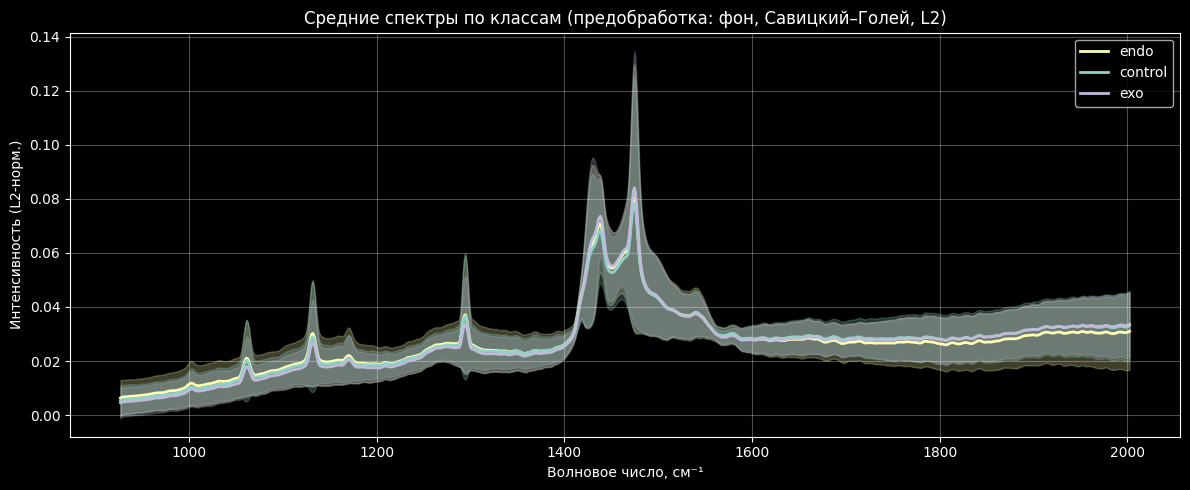

In [6]:
wavenumbers = np.array([float(c.replace("wave_", "")) for c in wave_cols])

fig, ax = plt.subplots(figsize=(12, 5))
colors = {"control": "C0", "endo": "C1", "exo": "C2"}
for cls in df["class"].unique():
    mask = df["class"] == cls
    spec = df.loc[mask, wave_cols].values
    mean_spec = spec.mean(axis=0)
    std_spec = spec.std(axis=0)
    ax.plot(wavenumbers, mean_spec, color=colors.get(cls, "gray"), label=cls, lw=2)
    ax.fill_between(wavenumbers, mean_spec - std_spec, mean_spec + std_spec, color=colors.get(cls, "gray"), alpha=0.25)
ax.set_xlabel("Волновое число, см⁻¹")
ax.set_ylabel("Интенсивность (L2-норм.)")
ax.set_title("Средние спектры по классам (предобработка: фон, Савицкий–Голей, L2)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

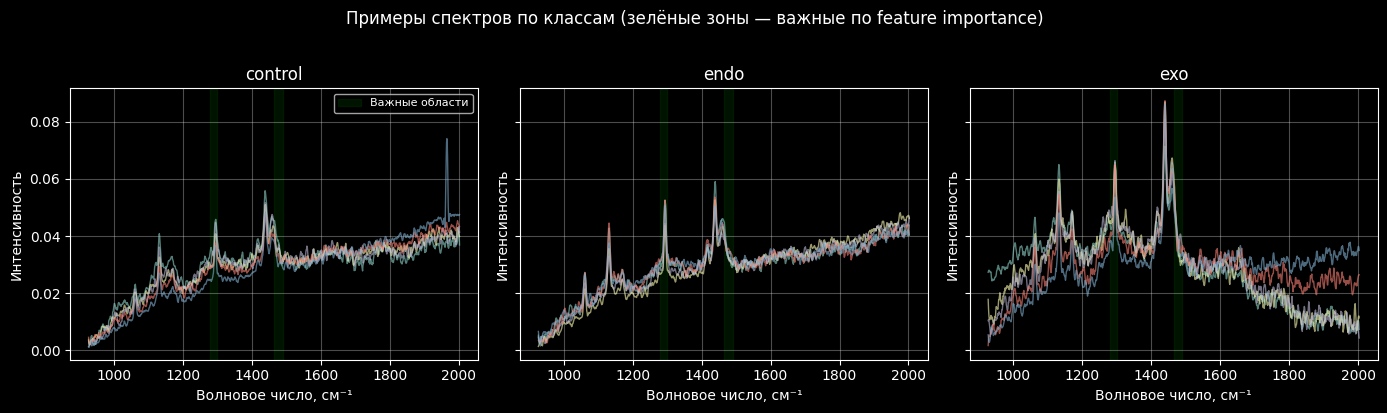

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
important_regions = [(1280, 1300), (1465, 1490)]
for i, cls in enumerate(["control", "endo", "exo"]):
    ax = axes[i]
    mask = df["class"] == cls
    sample = df.loc[mask, wave_cols].iloc[:5]
    for _, row in sample.iterrows():
        ax.plot(wavenumbers, row.values, alpha=0.6, lw=1)
    for (w0, w1) in important_regions:
        ax.axvspan(w0, w1, alpha=0.15, color="green", label="Важные области" if (w0, w1) == important_regions[0] else None)
    ax.set_xlabel("Волновое число, см⁻¹")
    ax.set_ylabel("Интенсивность")
    ax.set_title(cls)
    ax.grid(True, alpha=0.3)
axes[0].legend(loc="upper right", fontsize=8)
plt.suptitle("Примеры спектров по классам (зелёные зоны — важные по feature importance)", y=1.02)
plt.tight_layout()
plt.show()

## ⚠️ Проверка на data leakage (утечку по группам)

При случайном split по строкам строки из **одного source_file** попадают и в train, и в test. Спектры из одного файла (одного образца) почти идентичны — модель "подглядывает" в тесте. Ниже — диагностика.

In [8]:
from sklearn.model_selection import train_test_split

x_tmp = df.drop(['class','source_file','X','Y'], axis=1)
y_tmp = df['class']
x_tr, x_te, y_tr, y_te = train_test_split(x_tmp, y_tmp, test_size=0.2, random_state=42, shuffle=True)

train_files = set(df.loc[x_tr.index, 'source_file'])
test_files = set(df.loc[x_te.index, 'source_file'])
overlap = train_files & test_files

print(f"Уникальных source_file: {df['source_file'].nunique()}")
print(f"Файлов в train: {len(train_files)}, в test: {len(test_files)}")
print(f"Файлов в ОБОИХ (утечка!): {len(overlap)} ({100*len(overlap)/len(test_files):.1f}% теста)")

Уникальных source_file: 237
Файлов в train: 237, в test: 237
Файлов в ОБОИХ (утечка!): 237 (100.0% теста)


In [9]:
from sklearn.model_selection import GroupShuffleSplit

x = df.drop(['class','source_file','X','Y'], axis=1)
y = df['class']
groups = df['source_file']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(x, y, groups))

x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [10]:
train_files_new = set(df.loc[train_idx, 'source_file'])
test_files_new = set(df.loc[test_idx, 'source_file'])
print("Файлов в train:", len(train_files_new), "| в test:", len(test_files_new))
print("Пересечение (должно быть 0):", len(train_files_new & test_files_new))

Файлов в train: 189 | в test: 48
Пересечение (должно быть 0): 0


In [11]:
x_train_enc = pd.get_dummies(x_train, columns=['region'])
x_test_enc = pd.get_dummies(x_test, columns=['region'])
for c in x_train_enc.columns:
    if c not in x_test_enc.columns:
        x_test_enc[c] = 0
x_test_enc = x_test_enc[x_train_enc.columns]

from sklearn.preprocessing import StandardScaler, LabelEncoder
wave_cols_enc = [c for c in x_train_enc.columns if c.startswith('wave_')]
scaler = StandardScaler()
x_train_enc[wave_cols_enc] = scaler.fit_transform(x_train_enc[wave_cols_enc])
x_test_enc[wave_cols_enc] = scaler.transform(x_test_enc[wave_cols_enc])

le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)
print("Классы (метки):", dict(zip(le.classes_, range(len(le.classes_)))))

Классы (метки): {'control': 0, 'endo': 1, 'exo': 2}


In [12]:
RANDOM_STATE = 42
N_ESTIMATORS = 1200
MAX_DEPTH = 8
N_FOLDS = 5

groups_train = groups.iloc[train_idx].values
gkf = GroupKFold(n_splits=N_FOLDS)
n_classes = len(le.classes_)
n_base = 4
oof = np.zeros((len(y_train_num), n_classes * n_base))

def _ridge_proba(ridge, X):
    d = ridge.decision_function(X)
    if d.ndim == 1:
        d = d.reshape(-1, 1)
    e = np.exp(d - d.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

log.info("Старт обучения: N_FOLDS=%d, n_classes=%d, train_size=%d", N_FOLDS, n_classes, len(y_train_num))

for fold, (tr_idx, val_idx) in enumerate(gkf.split(x_train_enc, y_train_num, groups_train)):
    t_fold = time.perf_counter()
    x_tr, x_val = x_train_enc.iloc[tr_idx], x_train_enc.iloc[val_idx]
    y_tr, y_val = y_train_num[tr_idx], y_train_num[val_idx]
    log.info("Fold %d/%d | train: %d, val: %d", fold + 1, N_FOLDS, len(tr_idx), len(val_idx))

    t0 = time.perf_counter()
    m_lgbm = lgb.LGBMClassifier(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, learning_rate=0.04,
        num_leaves=2**MAX_DEPTH, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
        min_child_samples=30, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=THREAD_COUNT, verbose=-1)
    m_lgbm.fit(x_tr, y_tr, eval_set=[(x_val, y_val)], callbacks=[lgb.early_stopping(100, verbose=False)])
    log.info("  LGBM: %.1f s", time.perf_counter() - t0)

    t0 = time.perf_counter()
    m_cat = CatBoostClassifier(iterations=N_ESTIMATORS, depth=MAX_DEPTH, learning_rate=0.04,
        l2_leaf_reg=5, min_data_in_leaf=30, thread_count=THREAD_COUNT, used_ram_limit=USED_RAM_LIMIT, max_bin=128,
        auto_class_weights='Balanced', bootstrap_type='Bernoulli', subsample=0.8,
        random_state=RANDOM_STATE, verbose=0)
    m_cat.fit(x_tr, y_tr, eval_set=(x_val, y_val), early_stopping_rounds=100, verbose=0)
    log.info("  CatBoost: %.1f s", time.perf_counter() - t0)

    t0 = time.perf_counter()
    m_ridge = RidgeClassifier(alpha=2.0, class_weight='balanced', random_state=RANDOM_STATE)
    m_ridge.fit(x_tr, y_tr)
    log.info("  Ridge: %.1f s", time.perf_counter() - t0)

    t0 = time.perf_counter()
    m_sgd = SGDClassifier(loss='log_loss', max_iter=2000, tol=1e-4, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=THREAD_COUNT)
    m_sgd.fit(x_tr, y_tr)
    log.info("  SGD: %.1f s", time.perf_counter() - t0)

    oof[val_idx, 0:n_classes] = m_lgbm.predict_proba(x_val)
    oof[val_idx, n_classes:2*n_classes] = m_cat.predict_proba(x_val)
    oof[val_idx, 2*n_classes:3*n_classes] = _ridge_proba(m_ridge, x_val)
    oof[val_idx, 3*n_classes:4*n_classes] = m_sgd.predict_proba(x_val)

    acc_lgbm = accuracy_score(y_val, m_lgbm.predict(x_val))
    acc_cat = accuracy_score(y_val, m_cat.predict(x_val))
    acc_ridge = accuracy_score(y_val, m_ridge.predict(x_val))
    acc_sgd = accuracy_score(y_val, m_sgd.predict(x_val))
    log.info("  Val acc: LGBM=%.3f Cat=%.3f Ridge=%.3f SGD=%.3f | fold total: %.1f s",
             acc_lgbm, acc_cat, acc_ridge, acc_sgd, time.perf_counter() - t_fold)

log.info("OOF готов. Форма oof: %s", oof.shape)

log.info("Дообучение базовых моделей на полном train для предсказания на test...")
t0 = time.perf_counter()
m_lgbm = lgb.LGBMClassifier(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, learning_rate=0.04,
    num_leaves=2**MAX_DEPTH, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
    min_child_samples=30, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=THREAD_COUNT, verbose=-1)
m_lgbm.fit(x_train_enc, y_train_num)
m_cat = CatBoostClassifier(iterations=N_ESTIMATORS, depth=MAX_DEPTH, learning_rate=0.04,
    l2_leaf_reg=5, min_data_in_leaf=30, thread_count=THREAD_COUNT, used_ram_limit=USED_RAM_LIMIT, max_bin=128,
    auto_class_weights='Balanced', bootstrap_type='Bernoulli', subsample=0.8,
    random_state=RANDOM_STATE, verbose=0)
m_cat.fit(x_train_enc, y_train_num, verbose=0)
m_ridge = RidgeClassifier(alpha=2.0, class_weight='balanced', random_state=RANDOM_STATE)
m_ridge.fit(x_train_enc, y_train_num)
m_sgd = SGDClassifier(loss='log_loss', max_iter=2000, tol=1e-4, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=THREAD_COUNT)
m_sgd.fit(x_train_enc, y_train_num)
log.info("Базовые модели дообучены за %.1f s", time.perf_counter() - t0)

20:07:04 [INFO] Старт обучения: N_FOLDS=5, n_classes=3, train_size=99225
20:07:05 [INFO] Fold 1/5 | train: 79275, val: 19950
20:07:40 [INFO]   LGBM: 35.4 s
20:09:41 [INFO]   CatBoost: 120.6 s
20:09:43 [INFO]   Ridge: 1.7 s
20:10:12 [INFO]   SGD: 29.8 s
20:10:13 [INFO]   Val acc: LGBM=0.614 Cat=0.623 Ridge=0.478 SGD=0.505 | fold total: 188.7 s
20:10:14 [INFO] Fold 2/5 | train: 79275, val: 19950
20:10:44 [INFO]   LGBM: 30.5 s
20:12:48 [INFO]   CatBoost: 124.0 s
20:12:50 [INFO]   Ridge: 1.6 s
20:13:12 [INFO]   SGD: 21.7 s
20:13:12 [INFO]   Val acc: LGBM=0.679 Cat=0.666 Ridge=0.545 SGD=0.532 | fold total: 179.3 s
20:13:13 [INFO] Fold 3/5 | train: 79275, val: 19950
20:14:17 [INFO]   LGBM: 64.1 s
20:18:41 [INFO]   CatBoost: 264.3 s
20:18:43 [INFO]   Ridge: 1.6 s
20:19:07 [INFO]   SGD: 23.9 s
20:19:08 [INFO]   Val acc: LGBM=0.745 Cat=0.722 Ridge=0.575 SGD=0.564 | fold total: 355.2 s
20:19:08 [INFO] Fold 4/5 | train: 79275, val: 19950
20:19:38 [INFO]   LGBM: 29.7 s
20:21:13 [INFO]   CatBoost: 

In [13]:
t0 = time.perf_counter()
meta_learner = LogisticRegression(C=0.5, max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
meta_learner.fit(oof, y_train_num)
log.info("Мета-модель обучена на %d объектах, %d признаков за %.1f s", oof.shape[0], oof.shape[1], time.perf_counter() - t0)

from scipy.optimize import minimize
meta_proba_oof = meta_learner.predict_proba(oof)
control_ix, exo_ix = 0, 2
def _loss(w):
    w = np.maximum(np.asarray(w), 0.01)
    pred = np.argmax(meta_proba_oof * w, axis=1)
    f1 = f1_score(y_train_num, pred, average='macro', zero_division=0)
    n_control_as_exo = np.sum((y_train_num == control_ix) & (pred == exo_ix))
    n_exo_as_control = np.sum((y_train_num == exo_ix) & (pred == control_ix))
    penalty = 0.0005 * (n_control_as_exo + n_exo_as_control)
    return -f1 + penalty
x0_list = [[1.0, 1.0, 1.0], [0.9, 1.0, 1.1], [1.1, 1.0, 0.9], [0.85, 1.0, 1.15], [1.15, 1.0, 0.85]]
best_loss, best_w = np.inf, None
for x0 in x0_list:
    r = minimize(_loss, x0=x0, method='L-BFGS-B', bounds=[(0.4, 2.5)]*3)
    if r.fun < best_loss:
        best_loss, best_w = r.fun, r.x
class_weight_stack = np.array(best_w)
log.info("Множители по классам %s: %s", list(le.classes_), np.round(class_weight_stack, 3).tolist())

20:43:13 [INFO] Мета-модель обучена на 99225 объектах, 12 признаков за 0.3 s
20:43:13 [INFO] Множители по классам ['control', 'endo', 'exo']: [1.0, 1.0, 1.0]


In [14]:
p_lgbm = m_lgbm.predict_proba(x_test_enc)
p_cat  = m_cat.predict_proba(x_test_enc)
p_ridge = _ridge_proba(m_ridge, x_test_enc)
p_sgd   = m_sgd.predict_proba(x_test_enc)

test_stack = np.hstack([p_lgbm, p_cat, p_ridge, p_sgd])
meta_proba_test = meta_learner.predict_proba(test_stack)
y_pred_ensemble = np.argmax(meta_proba_test * class_weight_stack, axis=1)

In [15]:
def eval_model(name, y_pred):
    acc = accuracy_score(y_test_num, y_pred)
    p_macro = precision_score(y_test_num, y_pred, average='macro', zero_division=0)
    p_micro = precision_score(y_test_num, y_pred, average='micro', zero_division=0)
    p_wtd   = precision_score(y_test_num, y_pred, average='weighted', zero_division=0)
    r_macro = recall_score(y_test_num, y_pred, average='macro', zero_division=0)
    r_micro = recall_score(y_test_num, y_pred, average='micro', zero_division=0)
    r_wtd   = recall_score(y_test_num, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_test_num, y_pred, average='macro', zero_division=0)
    f1_micro = f1_score(y_test_num, y_pred, average='micro', zero_division=0)
    f1_wtd   = f1_score(y_test_num, y_pred, average='weighted', zero_division=0)
    r2 = r2_score(y_test_num, y_pred)
    print(f"{name:12} | Acc: {acc:.4f} | P_mac: {p_macro:.4f} P_mic: {p_micro:.4f} P_wtd: {p_wtd:.4f} | R_mac: {r_macro:.4f} R_mic: {r_micro:.4f} R_wtd: {r_wtd:.4f} | F1_mac: {f1_macro:.4f} F1_mic: {f1_micro:.4f} F1_wtd: {f1_wtd:.4f} | R2: {r2:.4f}")

y_pred_lgbm  = m_lgbm.predict(x_test_enc)
y_pred_cat   = m_cat.predict(x_test_enc)
y_pred_ridge = m_ridge.predict(x_test_enc)
y_pred_sgd   = m_sgd.predict(x_test_enc)

eval_model("LGBM",      y_pred_lgbm)
eval_model("CatBoost",  y_pred_cat)
eval_model("Ridge",     y_pred_ridge)
eval_model("SGD",       y_pred_sgd)
eval_model("Stacking",  y_pred_ensemble)

print("\n--- Confusion matrix (Stacking) ---")
cm = confusion_matrix(y_test_num, y_pred_ensemble)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
cm_df.index.name = "True \u2192"
cm_df.columns.name = "Pred"
display(cm_df)
print("\n--- Classification report (Stacking) ---")
print(classification_report(y_test_num, y_pred_ensemble, target_names=le.classes_, zero_division=0))

LGBM         | Acc: 0.5895 | P_mac: 0.6293 P_mic: 0.5895 P_wtd: 0.6612 | R_mac: 0.6053 R_mic: 0.5895 R_wtd: 0.5895 | F1_mac: 0.5840 F1_mic: 0.5895 F1_wtd: 0.5870 | R2: -0.4837
CatBoost     | Acc: 0.5922 | P_mac: 0.6247 P_mic: 0.5922 P_wtd: 0.6560 | R_mac: 0.6040 R_mic: 0.5922 R_wtd: 0.5922 | F1_mac: 0.5859 F1_mic: 0.5922 F1_wtd: 0.5914 | R2: -0.4981
Ridge        | Acc: 0.4369 | P_mac: 0.4440 P_mic: 0.4369 P_wtd: 0.4604 | R_mac: 0.4430 R_mic: 0.4369 R_wtd: 0.4369 | F1_mac: 0.4344 F1_mic: 0.4369 F1_wtd: 0.4385 | R2: -0.8591
SGD          | Acc: 0.4421 | P_mac: 0.4476 P_mic: 0.4421 P_wtd: 0.4627 | R_mac: 0.4500 R_mic: 0.4421 R_wtd: 0.4421 | F1_mac: 0.4392 F1_mic: 0.4421 F1_wtd: 0.4416 | R2: -0.7806
Stacking     | Acc: 0.6073 | P_mac: 0.6355 P_mic: 0.6073 P_wtd: 0.6655 | R_mac: 0.6187 R_mic: 0.6073 R_wtd: 0.6073 | F1_mac: 0.6006 F1_mic: 0.6073 F1_wtd: 0.6061 | R2: -0.4255

--- Confusion matrix (Stacking) ---


Pred,control,endo,exo
True →,,,
control,3791,404,2630
endo,3045,5078,2377
exo,1035,406,6434



--- Classification report (Stacking) ---
              precision    recall  f1-score   support

     control       0.48      0.56      0.52      6825
        endo       0.86      0.48      0.62     10500
         exo       0.56      0.82      0.67      7875

    accuracy                           0.61     25200
   macro avg       0.64      0.62      0.60     25200
weighted avg       0.67      0.61      0.61     25200



In [16]:
feat_names = x_train_enc.columns.tolist()

imp_lgbm  = m_lgbm.feature_importances_
imp_cat   = m_cat.get_feature_importance()
imp_ridge = np.abs(m_ridge.coef_).sum(axis=0)
imp_sgd   = np.abs(m_sgd.coef_).sum(axis=0)

fi = pd.DataFrame({
    "feature": feat_names,
    "LGBM":     imp_lgbm,
    "CatBoost": imp_cat,
    "Ridge":    imp_ridge,
    "SGD":      imp_sgd,
})
fi_norm = fi[["LGBM", "CatBoost", "Ridge", "SGD"]].apply(
    lambda c: (c - c.min()) / (c.max() - c.min()) if c.max() > c.min() else c
)
fi["mean_imp"] = fi_norm.mean(axis=1)
fi = fi.sort_values("mean_imp", ascending=False).reset_index(drop=True)

print("--- Top-25 признаков (по средней важности) ---")
display(fi.head(25))

meta_feat = (
    [f"LGBM_{c}" for c in le.classes_] + [f"Cat_{c}" for c in le.classes_] +
    [f"Ridge_{c}" for c in le.classes_] + [f"SGD_{c}" for c in le.classes_]
)
meta_imp = np.abs(meta_learner.coef_).sum(axis=0)
meta_fi = pd.DataFrame({"meta_feature": meta_feat, "importance": meta_imp}).sort_values("importance", ascending=False)
print("\n--- Важность входов мета-модели (стеккинг) ---")
display(meta_fi)

--- Top-25 признаков (по средней важности) ---


,feature,LGBM,CatBoost,Ridge,SGD,mean_imp
0,center_1500,780,0.787927,2.748809,10.099080,0.564645
1,region_cerebellum_right,2749,8.198649,0.707071,2.878402,0.552284
2,region_cortex,4012,6.662806,0.243199,0.923181,0.496330
3,region_cerebellum_left,2625,5.663734,0.556880,2.389415,0.441086
4,region_cortex_left,3332,3.995734,0.276227,1.438818,0.386773
5,region_cortex_right,2675,2.645259,0.692234,2.568005,0.369089
6,wave_1290.13,2760,0.977589,0.942514,2.045799,0.333651
7,wave_1477.87,1392,0.314027,1.562950,2.280542,0.287327
8,wave_1482.11,591,0.095291,2.305543,1.865863,0.286338
9,region_striatum_left,2279,2.627084,0.411110,1.207371,0.283402



--- Важность входов мета-модели (стеккинг) ---


,meta_feature,importance
6,Ridge_control,3.862571
4,Cat_endo,2.982436
10,SGD_endo,2.363106
7,Ridge_endo,2.296697
2,LGBM_exo,2.213363
5,Cat_exo,1.812829
3,Cat_control,1.776253
1,LGBM_endo,1.676316
8,Ridge_exo,1.460085
11,SGD_exo,1.396136


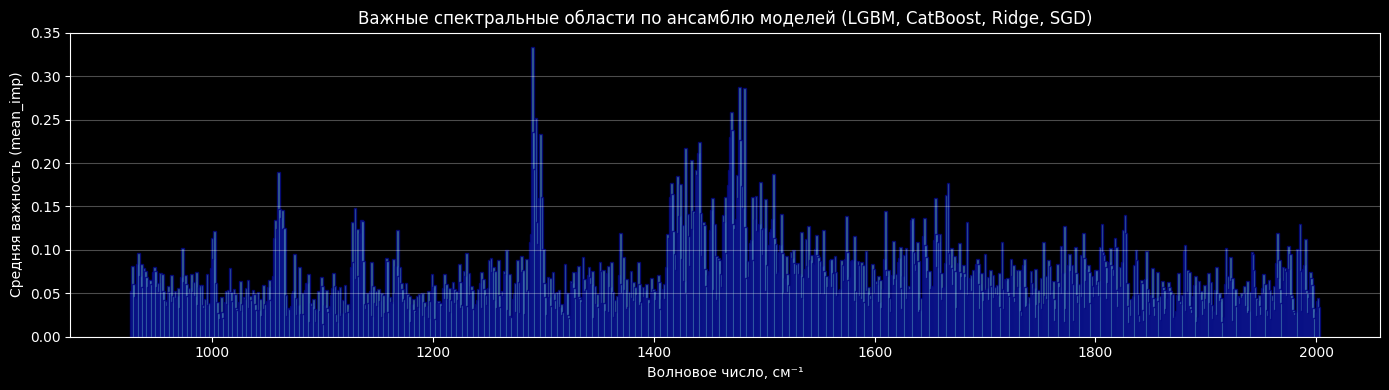

In [17]:
fi_wave = fi[fi["feature"].str.startswith("wave_")].copy()
fi_wave["wavenumber"] = fi_wave["feature"].str.replace("wave_", "").astype(float)
fi_wave = fi_wave.sort_values("wavenumber")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(fi_wave["wavenumber"], fi_wave["mean_imp"], width=2.5, color="steelblue", alpha=0.8, edgecolor="navy")
ax.set_xlabel("Волновое число, см⁻¹")
ax.set_ylabel("Средняя важность (mean_imp)")
ax.set_title("Важные спектральные области по ансамблю моделей (LGBM, CatBoost, Ridge, SGD)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Экспорт модели для веб-сервиса

Сохраняем модели в **нативных форматах** (без pickle): LGBM, CatBoost; Ridge и SGD в `meta.joblib`. В папке `model_export/` появятся файлы моделей и `meta.joblib` с мета-моделью, кодировщиком и списком признаков.

In [18]:
import joblib
from pathlib import Path

export_dir = Path("model_export")
export_dir.mkdir(exist_ok=True)

m_lgbm.booster_.save_model(str(export_dir / "lgbm.txt"))
m_cat.save_model(str(export_dir / "catboost.cbm"))

meta = {
    "meta_learner": meta_learner,
    "label_encoder": le,
    "class_weight_stack": class_weight_stack,
    "feature_columns": x_train_enc.columns.tolist(),
    "wave_cols": wave_cols,
    "savgol_window": 11,
    "savgol_poly": 3,
    "model_ridge": m_ridge,
    "model_sgd": m_sgd,
}
joblib.dump(meta, export_dir / "meta.joblib")
print("Модели сохранены в", export_dir.absolute())
print("Файлы:", list(export_dir.iterdir()))

Модели сохранены в C:\Users\alexk\PycharmProjects\RomanSpectre\model_export
Файлы: [WindowsPath('model_export/catboost.cbm'), WindowsPath('model_export/lgbm.txt'), WindowsPath('model_export/meta.joblib'), WindowsPath('model_export/xgb.json')]
